# Financial Risk Analysis with Python  
## Task 2: Descriptive Transactional Analysis   

**Objective:**  
To analyze customer transaction behavior by calculating monthly and yearly summaries of total credits, debits, and net transaction volume, enabling identification of financial inflow and outflow trends over time.


In [3]:
# Load cleaned transaction data
import pandas as pd

df = pd.read_csv("cleaned_transactions.csv")

# Ensure transaction date is in datetime format
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

df.head()


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,year,month
0,78,CUST1223,ACC33287,credit,withdrawal,Savings Account,Firm E,South,Manager 4,2023-06-01,81300.425190,40843.56193,0.330474,484,13,2023.0,2023-06
1,21,CUST8266,ACC58667,savings,withdrawal,Credit Card,Firm A,South,Manager 2,NaT,9269.640373,61183.03953,0.089688,836,18,NaN,NaN
2,176,CUST9420,ACC99117,credit,transfer,Home Loan,Firm A,East,Manager 1,NaT,28138.552650,85460.13405,0.340010,451,25,NaN,NaN
3,167,CUST5253,ACC10117,loan,payment,Mutual Fund,Firm D,Central,Manager 1,NaT,83943.556980,100525.35900,0.605383,487,13,NaN,NaN
4,46,CUST1223,ACC74631,savings,deposit,Credit Card,Firm A,East,Manager 4,2023-12-05,77104.456470,57425.69930,1.042441,393,10,2023.0,2023-12


In [5]:
# Task 2: Calculate monthly and yearly credits, debits, and net transaction volume

# Standardize transaction type
df['TransactionType'] = df['TransactionType'].str.lower().str.strip()

# Classify transactions as credit or debit
df['credit_debit'] = df['TransactionType'].map({
    'deposit': 'credit',
    'transfer': 'credit',
    'payment': 'debit',
    'withdrawal': 'debit'
})

# Create year and month columns
df['year'] = df['TransactionDate'].dt.year
df['month'] = df['TransactionDate'].dt.to_period('M')

# Monthly summary
monthly_summary = (
    df.groupby(['month', 'credit_debit'])['TransactionAmount']
      .sum()
      .unstack(fill_value=0)
)

monthly_summary['net_transaction'] = (
    monthly_summary['credit'] - monthly_summary['debit']
)

# Yearly summary
yearly_summary = (
    df.groupby(['year', 'credit_debit'])['TransactionAmount']
      .sum()
      .unstack(fill_value=0)
)

yearly_summary['net_transaction'] = (
    yearly_summary['credit'] - yearly_summary['debit']
)

# View results
monthly_summary.head()
yearly_summary


credit_debit,credit,debit,net_transaction
year,,,
2023.0,5.517018e+06,5.784106e+06,-267088.018255
2024.0,2.848000e+06,2.812055e+06,35944.295292


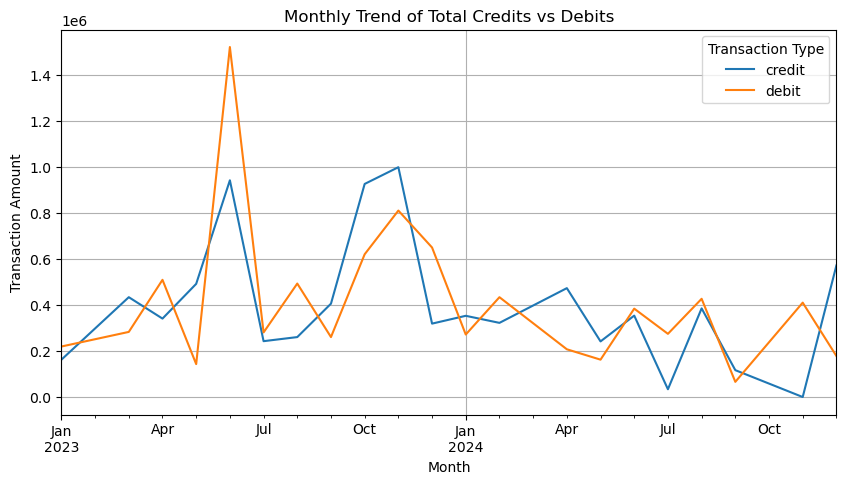

In [6]:
# Plot monthly trends of total credits vs debits
import matplotlib.pyplot as plt

monthly_summary[['credit', 'debit']].plot(kind='line', figsize=(10, 5))
plt.title('Monthly Trend of Total Credits vs Debits')
plt.xlabel('Month')
plt.ylabel('Transaction Amount')
plt.legend(title='Transaction Type')
plt.grid(True)
plt.show()


In [7]:
# Identify top and bottom performing accounts based on net inflow

# Calculate net inflow per account (credit - debit)
account_performance = (
    df.groupby(['AccountID', 'credit_debit'])['TransactionAmount']
      .sum()
      .unstack(fill_value=0)
)

account_performance['net_inflow'] = (
    account_performance['credit'] - account_performance['debit']
)

# Top 5 accounts by net inflow
top_accounts = account_performance.sort_values(
    by='net_inflow', ascending=False
).head(5)

# Bottom 5 accounts by net inflow
bottom_accounts = account_performance.sort_values(
    by='net_inflow', ascending=True
).head(5)

top_accounts, bottom_accounts


(credit_debit        credit         debit    net_inflow
 AccountID                                             
 ACC99549      575752.64702   53636.57769  522116.06933
 ACC57700      328840.57400       0.00000  328840.57400
 ACC95774      313828.49425       0.00000  313828.49425
 ACC48501      462332.99591  151655.14972  310677.84619
 ACC74631      278462.66736  -12893.46263  291356.12999,
 credit_debit       credit          debit     net_inflow
 AccountID                                              
 ACC19178      62859.62790  491586.399450 -428726.771550
 ACC77592          0.00000  411152.932010 -411152.932010
 ACC33287      34882.50354  399117.679070 -364235.175530
 ACC19156          0.00000  297506.791422 -297506.791422
 ACC23736      71107.97148  321777.235490 -250669.264010)

In [8]:
# Identify dormant accounts with a gap of 2 months or more between transactions

# Sort data by account and transaction date
df_sorted = df.sort_values(['AccountID', 'TransactionDate'])

# Calculate gap (in days) between consecutive transactions per account
df_sorted['gap_days'] = (
    df_sorted.groupby('AccountID')['TransactionDate']
             .diff()
             .dt.days
)

# Flag dormant transactions (gap >= 60 days)
df_sorted['dormant_flag'] = df_sorted['gap_days'] >= 60

# Identify dormant accounts
dormant_accounts = (
    df_sorted[df_sorted['dormant_flag']]
    [['AccountID']]
    .drop_duplicates()
)

dormant_accounts.head()


,AccountID
753,ACC10117
510,ACC11188
219,ACC11837
61,ACC12334
159,ACC13357
